## Data Generation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
import os
import torch
import shutil

# REPRODUCIBILITY
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Make CUDA operations as reproducible as practical
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# PHYSICAL PARAMETERS
hbar = 1.0
m = 1.0
L = 1.0

# NUMERICAL PARAMETERS
Nx = 100
Nt = 200
dt = 0.001

x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

print("=" * 70)
print("INFINITE WELL — CRANK-NICOLSON DATA GENERATION")
print("=" * 70)

print(f"Spatial points Nx      = {Nx}")
print(f"Time steps Nt          = {Nt}")
print(f"dx                    = {dx:.8f}")
print(f"dt                    = {dt}")
print(f"Simulation time       = {Nt * dt:.6f}")


# CRANK NICOLSON MATRICES
r = 1j * hbar * dt / (4.0 * m * dx**2)

N_internal = Nx - 2

# Matrix B
B = (
    np.diag(
        (1 - 2 * r) * np.ones(N_internal)
    )
    +
    np.diag(
        r * np.ones(N_internal - 1),
        1
    )
    +
    np.diag(
        r * np.ones(N_internal - 1),
        -1
    )
)


# Matrix A
A_banded = np.zeros(
    (3, N_internal),
    dtype=complex
)

A_banded[0, 1:] = -r
A_banded[1, :] = 1 + 2 * r
A_banded[2, :-1] = -r


# HELPER FUNCTIONS
def normalize_wavefunction(psi, x):
    """
    Normalize wavefunction using numerical integration.
    """

    probability = np.trapezoid(
        np.abs(psi)**2,
        x
    )

    if probability <= 0:
        raise ValueError(
            "Wavefunction has zero or invalid probability."
        )

    return psi / np.sqrt(probability)


# ----------------------------------------------------------

def ground_state(x, phase=0.0):
    """
    Infinite-well ground state.
    """

    psi = (
        np.sqrt(2.0)
        * np.sin(np.pi * x / L)
        * np.exp(1j * phase)
    )

    psi[0] = 0
    psi[-1] = 0

    return normalize_wavefunction(psi, x)


# ----------------------------------------------------------

def first_excited_state(x, phase=0.0):
    """
    Infinite-well first excited state.
    """

    psi = (
        np.sqrt(2.0)
        * np.sin(2.0 * np.pi * x / L)
        * np.exp(1j * phase)
    )

    psi[0] = 0
    psi[-1] = 0

    return normalize_wavefunction(psi, x)


# ----------------------------------------------------------

def gaussian_wavepacket(
    x,
    x0,
    sigma,
    k0
):

    psi = (
        np.exp(
            -(x - x0)**2 /
            (4.0 * sigma**2)
        )
        *
        np.exp(
            1j * k0 * x
        )
    )

    # Infinite well boundary conditions
    psi[0] = 0
    psi[-1] = 0

    return normalize_wavefunction(psi, x)


# ----------------------------------------------------------

def random_superposition(
    x,
    max_state=5
):

    coefficients = (
        np.random.randn(max_state)
        +
        1j * np.random.randn(max_state)
    )

    coefficients = (
        coefficients /
        np.linalg.norm(coefficients)
    )

    psi = np.zeros(
        len(x),
        dtype=complex
    )

    for n in range(1, max_state + 1):

        eigenstate = (
            np.sqrt(2.0)
            * np.sin(
                n * np.pi * x / L
            )
        )

        psi += coefficients[n - 1] * eigenstate

    psi[0] = 0
    psi[-1] = 0

    return normalize_wavefunction(psi, x)


# PROBABILITY
def calculate_probability(psi, x):

    return np.trapezoid(
        np.abs(psi)**2,
        x
    )


# ENERGY EXPECTATION VALUE
def calculate_energy(psi):
    second_derivative_interior = (psi[2:] - 2.0*psi[1:-1] + psi[:-2]) / dx**2
    Hpsi = np.zeros_like(psi)
    Hpsi[1:-1] = (-hbar**2/(2.0*m)) * second_derivative_interior
    numerator = np.trapezoid(np.conjugate(psi) * Hpsi, x)
    denominator = np.trapezoid(np.abs(psi)**2, x)
    return np.real(numerator/denominator)


# CRANK NICOLSON SOLVER
def crank_nicolson(
    psi_initial,
    x,
    Nt,
    dt
):

    psi = psi_initial.copy()

    trajectory = []

    probabilities = []

    energies = []

    times = []


    for n in range(Nt):

        t = n * dt

        # Store current state
        trajectory.append(
            psi.copy()
        )

        times.append(t)


        # Probability
        P = calculate_probability(
            psi,
            x
        )

        probabilities.append(P)


        # Energy
        E = calculate_energy(
            psi
        )

        energies.append(E)


        # Crank Nicolson update
        rhs = (
            B @ psi[1:-1]
        )

        psi_new_internal = solve_banded(
            (1, 1),
            A_banded,
            rhs
        )

        psi[1:-1] = (
            psi_new_internal
        )


        # Boundary conditions
        psi[0] = 0
        psi[-1] = 0


    return (
        np.array(trajectory),
        np.array(times),
        np.array(probabilities),
        np.array(energies)
    )


# CREATE INITIAL CONDITIONS
initial_conditions = []

# GROUND STATES
for i in range(10):

    phase = np.random.uniform(
        0,
        2 * np.pi
    )

    psi = ground_state(
        x,
        phase
    )

    initial_conditions.append(
        (
            f"ground_{i+1:02d}",
            "ground_state",
            psi
        )
    )


# FIRST EXCITED STATES
for i in range(10):

    phase = np.random.uniform(
        0,
        2 * np.pi
    )

    psi = first_excited_state(
        x,
        phase
    )

    initial_conditions.append(
        (
            f"excited_1_{i+1:02d}",
            "first_excited_state",
            psi
        )
    )


# GAUSSIAN WAVEPACKETS
for i in range(20):

    x0 = np.random.uniform(
        0.25,
        0.75
    )

    sigma = np.random.uniform(
        0.04,
        0.10
    )

    k0 = np.random.uniform(
        5.0,
        20.0
    )

    psi = gaussian_wavepacket(
        x,
        x0,
        sigma,
        k0
    )

    initial_conditions.append(
        (
            f"gaussian_{i+1:02d}",
            "gaussian_wavepacket",
            psi
        )
    )


# RANDOM SUPERPOSITIONS
for i in range(20):

    psi = random_superposition(
        x,
        max_state=5
    )

    initial_conditions.append(
        (
            f"superposition_{i+1:02d}",
            "superposition",
            psi
        )
    )


print("\nNumber of trajectories:")
print(
    len(initial_conditions)
)


# CREATE OUTPUT DIRECTORY
output_directory = (
    "infinite_well_datasets"
)

os.makedirs(
    output_directory,
    exist_ok=True
)


# RUN ALL CRANK NICOLSON SIMULATIONS
all_data = []

validation_results = []


for trajectory_id, initial_type, psi_initial in initial_conditions:

    print(
        f"Generating: "
        f"{trajectory_id:20s} | "
        f"{initial_type}"
    )


    # Run CN
    (
        trajectory,
        times,
        probabilities,
        energies
    ) = crank_nicolson(
        psi_initial,
        x,
        Nt,
        dt
    )


    # VALIDATION
    P_min = probabilities.min()
    P_max = probabilities.max()

    P_deviation = (
        P_max - P_min
    )

    E_initial = energies[0]
    E_final = energies[-1]

    E_drift = (
        E_final - E_initial
    )

    E_relative_drift = (
        abs(E_drift)
        /
        max(abs(E_initial), 1e-12)
    )


    # Boundary condition check
    boundary_error = np.max(
        np.abs(
            trajectory[:, 0]
        )
    )

    boundary_error_right = np.max(
        np.abs(
            trajectory[:, -1]
        )
    )


    # SAVE INDIVIDUAL CSV
    rows = []


    for time_index, t in enumerate(times):

        psi_t = trajectory[
            time_index
        ]

        for xi, psi_value in zip(
            x,
            psi_t
        ):

            rows.append(
                [
                    xi,
                    t,
                    psi_value.real,
                    psi_value.imag,
                    trajectory_id,
                    initial_type
                ]
            )


    trajectory_df = pd.DataFrame(
        rows,
        columns=[
            "x",
            "t",
            "psi_real",
            "psi_imag",
            "trajectory_id",
            "initial_condition"
        ]
    )


    filename = os.path.join(
        output_directory,
        f"{trajectory_id}.csv"
    )

    trajectory_df.to_csv(
        filename,
        index=False
    )



    # ADD TO COMBINED DATASET
    all_data.append(
        trajectory_df
    )


    # VALIDATION RESULTS
    validation_results.append(
        {
            "trajectory_id":
                trajectory_id,

            "initial_condition":
                initial_type,

            "P_min":
                P_min,

            "P_max":
                P_max,

            "P_deviation":
                P_deviation,

            "E_initial":
                E_initial,

            "E_final":
                E_final,

            "E_drift":
                E_drift,

            "E_relative_drift":
                E_relative_drift,

            "left_boundary_error":
                boundary_error,

            "right_boundary_error":
                boundary_error_right
        }
    )


# COMBINE ALL TRAJECTORIES
combined_df = pd.concat(
    all_data,
    ignore_index=True
)


combined_filename = (
    "infinite_well_all_trajectories.csv"
)

combined_df.to_csv(
    combined_filename,
    index=False
)


# VALIDATION TABLE
validation_df = pd.DataFrame(
    validation_results
)


validation_filename = (
    "infinite_well_validation_results.csv"
)

validation_df.to_csv(
    validation_filename,
    index=False
)


# PRINT VALIDATION SUMMARY
print("\n")
print("=" * 80)
print("CRANK-NICOLSON VALIDATION SUMMARY")
print("=" * 80)

print(
    validation_df[
        [
            "trajectory_id",
            "initial_condition",
            "P_min",
            "P_max",
            "P_deviation",
            "E_relative_drift",
            "left_boundary_error",
            "right_boundary_error"
        ]
    ].to_string(index=False)
)


# GLOBAL VALIDATION
print("\n")
print("=" * 70)
print("GLOBAL VALIDATION")
print("=" * 70)

print(
    f"Maximum probability deviation = "
    f"{validation_df['P_deviation'].max():.6e}"
)

print(
    f"Maximum relative energy drift = "
    f"{validation_df['E_relative_drift'].max():.6e}"
)

print(
    f"Maximum left boundary error = "
    f"{validation_df['left_boundary_error'].max():.6e}"
)

print(
    f"Maximum right boundary error = "
    f"{validation_df['right_boundary_error'].max():.6e}"
)


# ANALYTICAL VALIDATION — FIRST EXCITED STATE
print("\n")
print("=" * 70)
print("ANALYTICAL VALIDATION — FIRST EXCITED STATE")
print("=" * 70)

# Dedicated phase-zero first excited state
psi_initial_n2 = (
    np.sqrt(2)
    * np.sin(
        2 * np.pi * x / L
    )
).astype(complex)

psi_initial_n2[0] = 0
psi_initial_n2[-1] = 0

# Run Crank Nicolson
(
    trajectory_n2,
    times_n2,
    probabilities_n2,
    energies_n2
) = crank_nicolson(
    psi_initial_n2,
    x,
    Nt,
    dt
)

# Final numerical solution
psi_cn_n2 = trajectory_n2[-1]

final_time_n2 = times_n2[-1]

# Exact n=2 energy
E2 = (
    hbar**2
    * (2 * np.pi)**2
    /
    (2 * m * L**2)
)

# Analytical solution
psi_exact_n2 = (
    np.sqrt(2)
    * np.sin(
        2 * np.pi * x / L
    )
    *
    np.exp(
        -1j
        * E2
        * final_time_n2
        / hbar
    )
)

psi_exact_n2[0] = 0
psi_exact_n2[-1] = 0


# Error metrics
mse_n2 = np.mean(
    np.abs(
        psi_cn_n2 - psi_exact_n2
    )**2
)

rmse_n2 = np.sqrt(mse_n2)

max_error_n2 = np.max(
    np.abs(
        psi_cn_n2 - psi_exact_n2
    )
)

# Relative L2 error

relative_l2_n2 = (
    np.sqrt(
        np.sum(
            np.abs(
                psi_cn_n2 - psi_exact_n2
            ) ** 2
        ) * dx
    )
    /
    np.sqrt(
        np.sum(
            np.abs(
                psi_exact_n2
            ) ** 2
        ) * dx
    )
)


# Fidelity

overlap_n2 = (
    np.sum(
        np.conjugate(
            psi_exact_n2
        )
        *
        psi_cn_n2
    )
    * dx
)

fidelity_n2 = (
    np.abs(
        overlap_n2
    ) ** 2
)


# Fidelity error

fidelity_error_n2 = (
    1.0 - fidelity_n2
)

# Probability
P_min_n2 = np.min(
    probabilities_n2
)

P_max_n2 = np.max(
    probabilities_n2
)

P_dev_n2 = (
    P_max_n2 - P_min_n2
)


# Energy
E_initial_n2 = energies_n2[0]
E_final_n2 = energies_n2[-1]

energy_drift_n2 = abs(
    E_final_n2 - E_initial_n2
)

# Print results
print(f"Final simulation time = {final_time_n2:.6f}")

print("\nAccuracy:")
print(f"MSE                  = {mse_n2:.8e}")
print(f"RMSE                 = {rmse_n2:.8e}")
print(
    f"Maximum absolute error = "
    f"{max_error_n2:.8e}"
)
print(
    f"Minimum P            = "
    f"{P_min_n2:.12f}"
)
print(
    f"Maximum P            = "
    f"{P_max_n2:.12f}"
)
print(
    f"Probability deviation = "
    f"{P_dev_n2:.8e}"
)
print(
    f"Exact E2             = "
    f"{E2:.12e}"
)
print(
    f"Initial numerical E  = "
    f"{E_initial_n2:.12e}"
)
print(
    f"Final numerical E    = "
    f"{E_final_n2:.12e}"
)
print(
    f"Energy drift         = "
    f"{energy_drift_n2:.8e}"
)
print(
    f"Relative L2 error    = "
    f"{relative_l2_n2:.8e}"
)
print(
    f"Fidelity             = "
    f"{fidelity_n2:.12f}"
)
print(
    f"Fidelity error       = "
    f"{fidelity_error_n2:.8e}"
)


# Downloading File in drive
from google.colab import drive

drive.mount('/content/drive')

source_file = "/content/infinite_well_all_trajectories.csv"

drive_folder = "/content/drive/MyDrive/TDSE_Transformer"
os.makedirs(drive_folder, exist_ok=True)

destination_file = (
    f"{drive_folder}/infinite_well_all_trajectories.csv"
)

shutil.copy2(
    source_file,
    destination_file
)

print("File successfully copied to Google Drive.")
print(f"Location: {destination_file}")

file_path = "/content/drive/MyDrive/TDSE_Transformer/infinite_well_all_trajectories.csv"

file_size_mb = os.path.getsize(file_path) / (1024**2)

print(f"File size: {file_size_mb:.2f} MB")

df_check = pd.read_csv(file_path)

print(f"Rows: {len(df_check):,}")
print(f"Columns: {len(df_check.columns)}")

print("\nColumns:")
print(df_check.columns.tolist())

print("\nTrajectories:")
print(df_check["trajectory_id"].nunique())

print("\nInitial conditions:")
print(df_check["initial_condition"].value_counts())

print("\nFirst 5 rows:")
display(df_check.head())

print("\nLast 5 rows:")
display(df_check.tail())

INFINITE WELL — CRANK-NICOLSON DATA GENERATION
Spatial points Nx      = 100
Time steps Nt          = 200
dx                    = 0.01010101
dt                    = 0.001
Simulation time       = 0.200000

Number of trajectories:
60
Generating: ground_01            | ground_state
Generating: ground_02            | ground_state
Generating: ground_03            | ground_state
Generating: ground_04            | ground_state
Generating: ground_05            | ground_state
Generating: ground_06            | ground_state
Generating: ground_07            | ground_state
Generating: ground_08            | ground_state
Generating: ground_09            | ground_state
Generating: ground_10            | ground_state
Generating: excited_1_01         | first_excited_state
Generating: excited_1_02         | first_excited_state
Generating: excited_1_03         | first_excited_state
Generating: excited_1_04         | first_excited_state
Generating: excited_1_05         | first_excited_state
Generating: ex

,x,t,psi_real,psi_imag,trajectory_id,initial_condition
0,0.000000,0.0,0.000000,0.000000,ground_01,ground_state
1,0.010101,0.0,-0.031636,0.031819,ground_01,ground_state
2,0.020202,0.0,-0.063240,0.063607,ground_01,ground_state
3,0.030303,0.0,-0.094781,0.095330,ground_01,ground_state
4,0.040404,0.0,-0.126226,0.126958,ground_01,ground_state



Last 5 rows:


,x,t,psi_real,psi_imag,trajectory_id,initial_condition
1199995,0.959596,0.199,0.709528,0.364554,superposition_20,superposition
1199996,0.969697,0.199,0.545103,0.280933,superposition_20,superposition
1199997,0.979798,0.199,0.369658,0.190912,superposition_20,superposition
1199998,0.989899,0.199,0.186723,0.096552,superposition_20,superposition
1199999,1.000000,0.199,0.000000,0.000000,superposition_20,superposition


## Training & Testing

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1200000, 6)
          x    t  psi_real  psi_imag trajectory_id initial_condition
0  0.000000  0.0  0.000000  0.000000     ground_01      ground_state
1  0.010101  0.0 -0.031636  0.031819     ground_01      ground_state
2  0.020202  0.0 -0.063240  0.063607     ground_01      ground_state
3  0.030303  0.0 -0.094781  0.095330     ground_01      ground_state
4  0.040404  0.0 -0.126226  0.126958     ground_01      ground_state
initial_condition
superposition          400000
gaussian_wavepacket    400000
first_excited_state    200000
ground_state           200000
Name: count, dtype: int64
60
Number of trajectories: 60
ground_01 (200, 200)
Training trajectories: 48
Testing trajectories: 12

Training:
ground_state 8
first_excited_state 8
gaussian_wavepacket 16
superposition 16

Testing:
ground_state 2
first_excited_state 2
gaussian_wavepacket 4
superposi

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 001 | Train MSE: 6.563265e-01 | Test MSE: 3.299813e-01 | Test RMSE: 5.744400e-01 | P deviation: 3.576e-07
Epoch 010 | Train MSE: 2.133816e-02 | Test MSE: 1.558387e-02 | Test RMSE: 1.248354e-01 | P deviation: 3.576e-07
Epoch 020 | Train MSE: 5.572087e-03 | Test MSE: 6.147373e-03 | Test RMSE: 7.840519e-02 | P deviation: 2.384e-07
Epoch 030 | Train MSE: 2.392663e-03 | Test MSE: 3.473497e-03 | Test RMSE: 5.893638e-02 | P deviation: 3.576e-07
Epoch 040 | Train MSE: 1.189785e-03 | Test MSE: 1.967454e-03 | Test RMSE: 4.435599e-02 | P deviation: 3.576e-07
Epoch 050 | Train MSE: 6.614060e-04 | Test MSE: 1.183988e-03 | Test RMSE: 3.440912e-02 | P deviation: 2.980e-07
Epoch 060 | Train MSE: 4.094736e-04 | Test MSE: 7.629075e-04 | Test RMSE: 2.762078e-02 | P deviation: 3.576e-07
Epoch 070 | Train MSE: 2.783660e-04 | Test MSE: 5.296046e-04 | Test RMSE: 2.301314e-02 | P deviation: 2.980e-07
Epoch 080 | Train MSE: 2.005023e-04 | Test MSE: 3.858117e-04 | Test RMSE: 1.964209e-02 | P deviation: 3.

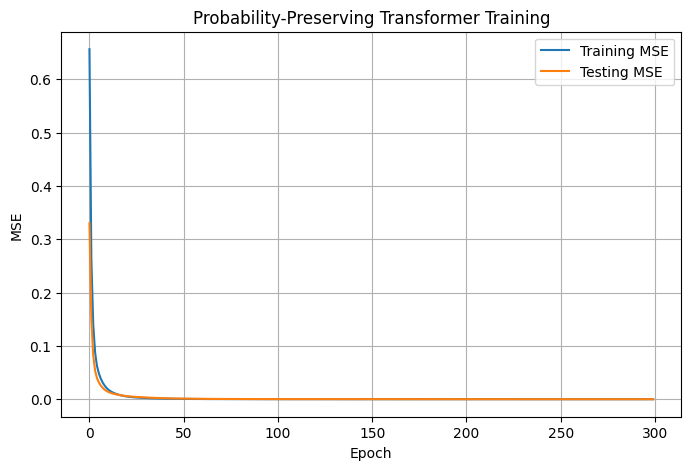

trajectory_id                gaussian_18
initial_condition    gaussian_wavepacket
timestep                              90
time                                0.09
mse                             0.000858
rmse                            0.029289
relative_l2                     0.041629
max_abs_error                   0.096076
real_rmse                       0.033412
imag_rmse                        0.02448
error_component                     real
max_error_x                     0.878788
P_pred                               1.0
P_true                               1.0
P_deviation                          0.0
P_error                              0.0
       trajectory_id    initial_condition  mean_rmse  max_rmse  \
5        gaussian_18  gaussian_wavepacket   0.016202  0.029289   
2        gaussian_02  gaussian_wavepacket   0.002803  0.005281   
8   superposition_02        superposition   0.001583  0.004294   
4        gaussian_14  gaussian_wavepacket   0.001970  0.002400   
3        gauss

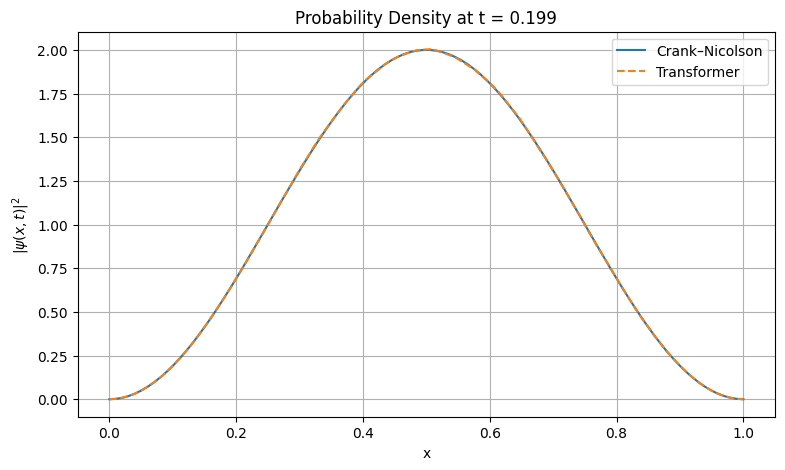

Energy diagnostics — all test trajectories
  trajectory_id initial_condition  timestep   time    E_true    E_pred  \
0     ground_02      ground_state         5  0.005  4.934388  4.945516   
1     ground_02      ground_state         6  0.006  4.934388  4.945536   
2     ground_02      ground_state         7  0.007  4.934388  4.945551   
3     ground_02      ground_state         8  0.008  4.934388  4.945562   
4     ground_02      ground_state         9  0.009  4.934388  4.945584   

   absolute_energy_error  relative_energy_error  
0               0.011128               0.002255  
1               0.011148               0.002259  
2               0.011163               0.002262  
3               0.011174               0.002264  
4               0.011196               0.002269  

Overall Energy Results
Mean relative energy error: 1.1674981560e-03
Maximum relative energy error: 2.4874530977e-02

Energy by initial-condition family
  initial_condition  mean_energy_error  max_energy_error  m

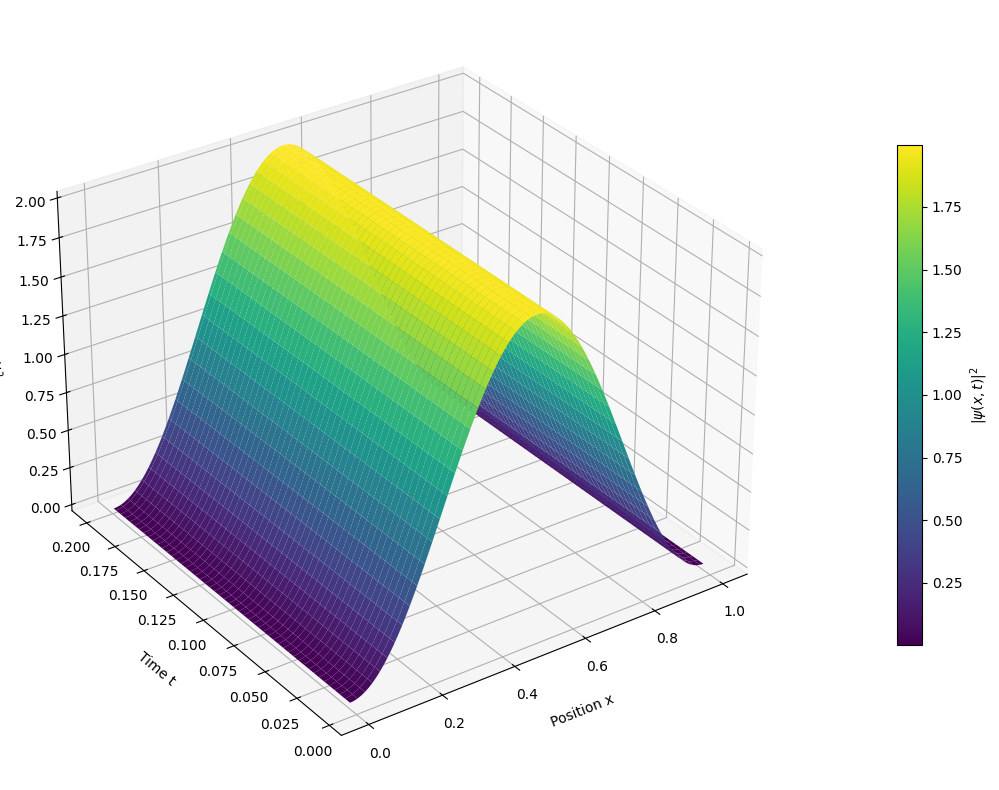

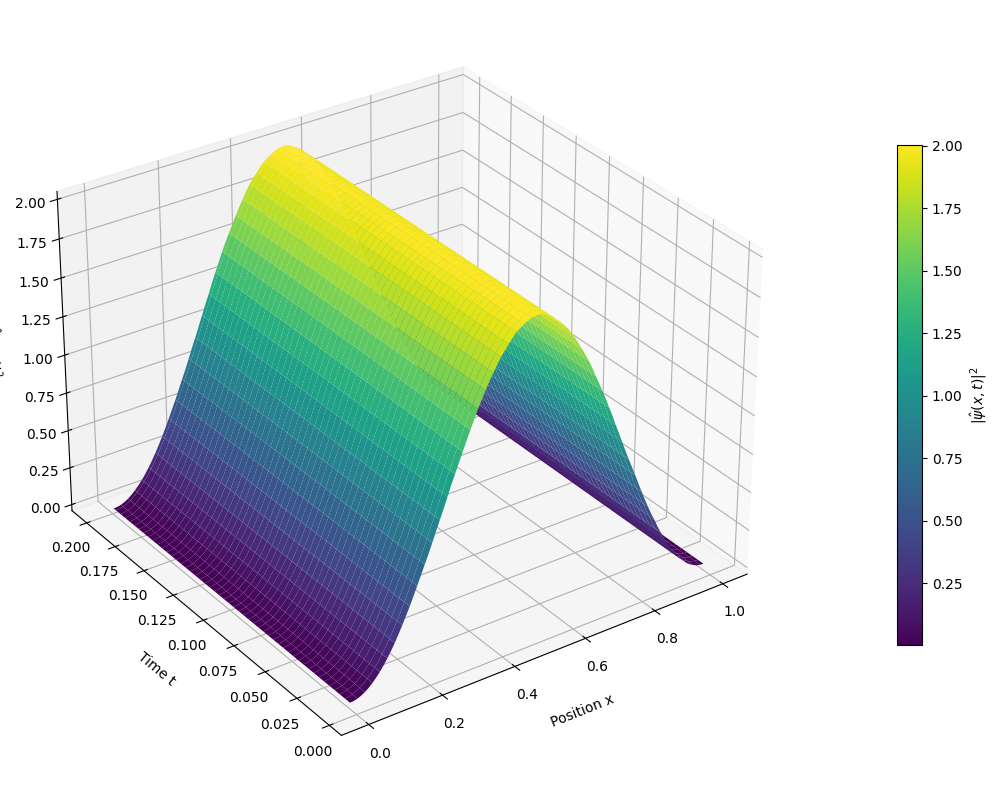

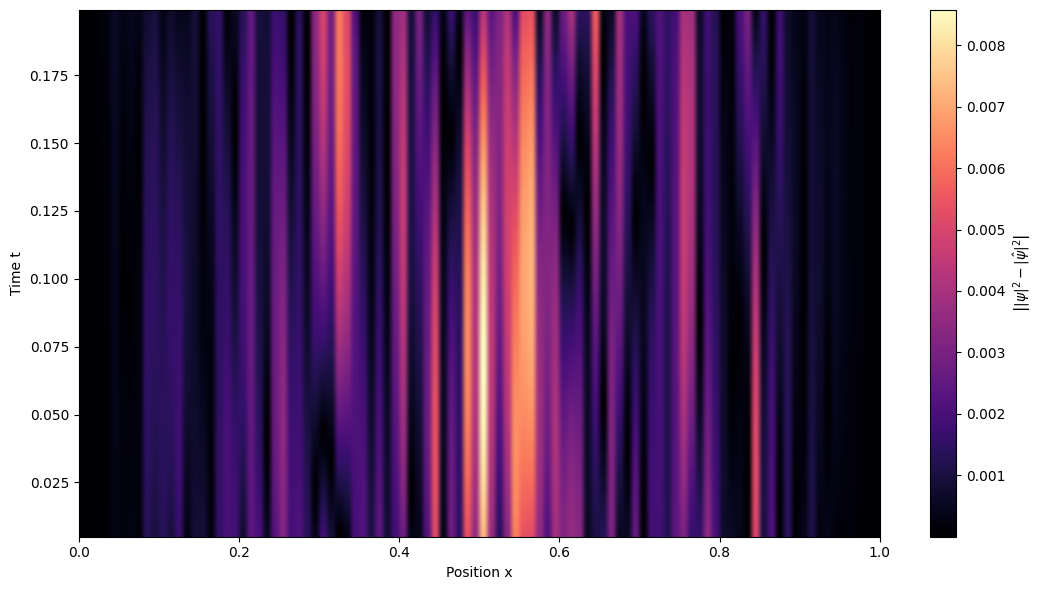

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import random
import os
from mpl_toolkits.mplot3d import Axes3D

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

from google.colab import drive

drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/TDSE_Transformer/infinite_well_all_trajectories.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df.head())
print(df["initial_condition"].value_counts())
print(df["trajectory_id"].nunique())


# Construct Wavefunction Trajectories
def build_trajectories(df):

    trajectories = {}

    grouped = df.groupby("trajectory_id", sort=False)

    for trajectory_id, group in grouped:

        group = group.sort_values(["t", "x"])

        times = np.sort(group["t"].unique())

        real = group["psi_real"].values.reshape(
            len(times), 100
        )

        imag = group["psi_imag"].values.reshape(
            len(times), 100
        )

        wavefunction = np.concatenate(
            [real, imag],
            axis=1
        )

        initial_condition = group["initial_condition"].iloc[0]

        trajectories[trajectory_id] = {
            "times": times,
            "wavefunction": wavefunction,
            "initial_condition": initial_condition
        }

    return trajectories

trajectories = build_trajectories(df)

print("Number of trajectories:", len(trajectories))

first_id = list(trajectories.keys())[0]

print(
    first_id,
    trajectories[first_id]["wavefunction"].shape
)



# Stratified Train/Test Split by Initial Condition Family
from collections import defaultdict

trajectory_groups = defaultdict(list)

for trajectory_id, data in trajectories.items():
    trajectory_groups[
        data["initial_condition"]
    ].append(trajectory_id)
train_ids = []
test_ids = []

for condition, ids in trajectory_groups.items():

    ids = sorted(ids)

    rng = np.random.default_rng(SEED)
    rng.shuffle(ids)

    n_train = int(0.8 * len(ids))

    train_ids.extend(ids[:n_train])
    test_ids.extend(ids[n_train:])
print("Training trajectories:", len(train_ids))
print("Testing trajectories:", len(test_ids))

print("\nTraining:")
for condition in trajectory_groups:
    print(
        condition,
        sum(
            trajectories[x]["initial_condition"] == condition
            for x in train_ids
        )
    )

print("\nTesting:")
for condition in trajectory_groups:
    print(
        condition,
        sum(
            trajectories[x]["initial_condition"] == condition
            for x in test_ids
        )
    )

# Temporal Sequence Dataset and DataLoader Preparation
WINDOW = 5
class WavefunctionSequenceDataset(Dataset):

    def __init__(
        self,
        trajectories,
        trajectory_ids,
        window=5
    ):

        self.samples = []

        for trajectory_id in trajectory_ids:

            data = trajectories[trajectory_id]

            wavefunction = data["wavefunction"]
            times = data["times"]

            for i in range(
                len(times) - window
            ):

                input_states = wavefunction[
                    i:i + window
                ]

                input_times = times[
                    i:i + window
                ]

                target_state = wavefunction[
                    i + window
                ]

                self.samples.append(
                    (
                        input_states.astype(np.float32),
                        input_times.astype(np.float32),
                        target_state.astype(np.float32),
                        trajectory_id
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        states, times, target, trajectory_id = self.samples[idx]

        return (
            torch.tensor(states),
            torch.tensor(times),
            torch.tensor(target),
            trajectory_id
        )
train_dataset = WavefunctionSequenceDataset(
    trajectories,
    train_ids,
    WINDOW
)

test_dataset = WavefunctionSequenceDataset(
    trajectories,
    test_ids,
    WINDOW
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Probability Preserving Multi Token Transformer Architecture
class ProbabilityPreservingMultiTokenTransformer(
    nn.Module
):

    def __init__(
        self,
        d_model=64,
        seq_len=5,
        dx=1.0 / 99
    ):

        super().__init__()

        self.d_model = d_model
        self.seq_len = seq_len
        self.dx = dx

        # Wavefunction token embedding
        self.state_embedding = nn.Linear(
            200,
            d_model
        )

        # Time embedding
        self.time_embedding = nn.Linear(
            1,
            d_model
        )

        # Learnable positional encoding
        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                seq_len,
                d_model
            ) * 0.02
        )

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Output wavefunction
        self.output = nn.Linear(
            d_model,
            200
        )


    def forward(
        self,
        states,
        times
    ):

        # states: (batch, 5, 200)
        # times: (batch, 5)

        state_tokens = self.state_embedding(
            states
        )

        time_tokens = self.time_embedding(
            times.unsqueeze(-1)
        )

        x = (
            state_tokens
            + time_tokens
            + self.pos_embedding
        )

        x = self.transformer(x)

        # Final temporal token
        x = x[:, -1, :]

        psi_hat = self.output(x)

        # Split real / imaginary
        real = psi_hat[:, :100]
        imag = psi_hat[:, 100:]

        # Probability
        probability = torch.sum(
            real**2 + imag**2,
            dim=1,
            keepdim=True
        ) * self.dx

        normalization_factor = torch.sqrt(
            probability + 1e-12
        )

        # HARD PROBABILITY CONSTRAINT
        real = (
            real /
            normalization_factor
        )

        imag = (
            imag /
            normalization_factor
        )

        psi = torch.cat(
            [real, imag],
            dim=1
        )

        return psi
model = ProbabilityPreservingMultiTokenTransformer(
    d_model=64,
    seq_len=WINDOW,
    dx=1.0 / 99
).to(device)

print(model)

# Boundary Aware Loss Function and Model Optimization
class BoundaryAwareLoss(nn.Module):

    def __init__(self, alpha=0.3, n_spatial=100):
        super().__init__()
        self.alpha = alpha

        # Boundary weight: peaks near x=0 and x=1
        x = torch.linspace(0, 1, n_spatial)
        boundary_weight = torch.exp(
            -10 * x * (1 - x)
        )

        # Repeat for real and imaginary components
        self.register_buffer(
            'boundary_weight',
            torch.cat([boundary_weight, boundary_weight])
            .unsqueeze(0)   # (1, 200)
        )

    def forward(self, pred, target):

        error = (pred - target) ** 2

        # Standard MSE
        mse = error.mean()

        # Boundary weighted MSE
        boundary_loss = (
            error * self.boundary_weight
        ).mean()

        return mse + self.alpha * boundary_loss

criterion = BoundaryAwareLoss(
    alpha=0.3,
    n_spatial=100
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Transformer Training Procedure
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0.0

    for states, times, target, _ in loader:

        states = states.to(device)
        times = times.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        prediction = model(
            states,
            times
        )

        loss = criterion(
            prediction,
            target
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() *
            states.size(0)
        )

    return (
        total_loss /
        len(loader.dataset)
    )


# Model Evaluation and Error Metric Calculation
def evaluate(
    model,
    loader,
    dx=1.0 / 99
):

    model.eval()

    total_mse = 0.0
    total_samples = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for states, times, target, _ in loader:

            states = states.to(device)
            times = times.to(device)
            target = target.to(device)

            prediction = model(
                states,
                times
            )

            batch_size = states.size(0)

            mse = torch.sum(
                (prediction - target) ** 2
            ).item()

            total_mse += mse
            total_samples += (
                batch_size * 200
            )

            all_predictions.append(
                prediction.cpu()
            )

            all_targets.append(
                target.cpu()
            )

    predictions = torch.cat(
        all_predictions
    ).numpy()

    targets = torch.cat(
        all_targets
    ).numpy()

    mse = (
        np.mean(
            (predictions - targets) ** 2
        )
    )

    rmse = np.sqrt(mse)

    max_abs_error = np.max(
        np.abs(
            predictions - targets
        )
    )

    # Relative L2 error
    relative_l2 = (
        np.linalg.norm(
            predictions - targets
        )
        /
        np.linalg.norm(targets)
    )

    # Probability
    pred_real = predictions[:, :100]
    pred_imag = predictions[:, 100:]

    target_real = targets[:, :100]
    target_imag = targets[:, 100:]

    predicted_probability = (
        np.sum(
            pred_real**2 +
            pred_imag**2,
            axis=1
        ) * dx
    )

    target_probability = (
        np.sum(
            target_real**2 +
            target_imag**2,
            axis=1
        ) * dx
    )

    probability_error = np.abs(
        predicted_probability - 1.0
    )

    target_probability_error = np.abs(
        target_probability - 1.0
    )

    return {
        "mse": mse,
        "rmse": rmse,
        "relative_l2": relative_l2,
        "max_abs_error": max_abs_error,

        "P_min": predicted_probability.min(),
        "P_max": predicted_probability.max(),
        "P_mean": predicted_probability.mean(),
        "P_std": predicted_probability.std(),
        "P_max_deviation": probability_error.max(),

        "target_P_max_deviation":
            target_probability_error.max()
    }


# Transformer Training, Best Model Selection, and Final Evaluation
EPOCHS = 300

history = {
    "train_loss": [],
    "test_mse": [],
    "test_rmse": []
}

best_test_mse = np.inf

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    metrics = evaluate(
        model,
        test_loader
    )

    history["train_loss"].append(
        train_loss
    )

    history["test_mse"].append(
        metrics["mse"]
    )

    history["test_rmse"].append(
        metrics["rmse"]
    )

    if metrics["mse"] < best_test_mse:

        best_test_mse = metrics["mse"]

        torch.save(
            model.state_dict(),
            "best_probability_preserving_transformer.pt"
        )

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train MSE: {train_loss:.6e} | "
            f"Test MSE: {metrics['mse']:.6e} | "
            f"Test RMSE: {metrics['rmse']:.6e} | "
            f"P deviation: "
            f"{metrics['P_max_deviation']:.3e}"
        )
model.load_state_dict(
    torch.load(
        "best_probability_preserving_transformer.pt",
        map_location=device
    )
)

model.eval()
final_metrics = evaluate(
    model,
    test_loader
)

# Final Performance Metrics and Training Curve Visualization
for key, value in final_metrics.items():
    print(
        f"{key:30s}: {value:.10e}"
    )
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training MSE"
)

plt.plot(
    history["test_mse"],
    label="Testing MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(
    "Probability-Preserving Transformer Training"
)

plt.legend()
plt.grid(True)

plt.show()

# Performance Evaluation Across Initial Condition Families
def evaluate_by_initial_condition(
    model,
    trajectories,
    test_ids
):

    results = []

    conditions = sorted(
        set(
            trajectories[x]["initial_condition"]
            for x in test_ids
        )
    )

    for condition in conditions:

        ids = [
            x for x in test_ids
            if trajectories[x]["initial_condition"]
            == condition
        ]

        dataset = WavefunctionSequenceDataset(
            trajectories,
            ids,
            WINDOW
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        metrics = evaluate(
            model,
            loader
        )

        metrics["initial_condition"] = condition
        metrics["n_trajectories"] = len(ids)
        metrics["n_samples"] = len(dataset)

        results.append(metrics)

    return pd.DataFrame(results)


# SINGLE TRAJECTORY PREDICTION
def predict_trajectory(
    model,
    trajectory,
    window=5
):

    model.eval()

    states = trajectory["wavefunction"]
    times = trajectory["times"]

    predictions = []
    targets = []

    with torch.no_grad():

        for i in range(
            len(times) - window
        ):

            input_states = torch.tensor(
                states[i:i+window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            input_times = torch.tensor(
                times[i:i+window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            prediction = model(
                input_states,
                input_times
            )

            predictions.append(
                prediction.cpu().numpy()[0]
            )

            targets.append(
                states[i+window]
            )

    return (
        np.array(predictions),
        np.array(targets)
    )


# DETAILED TEST SET ERROR DIAGNOSTICS
def diagnose_all_test_trajectories(
    model,
    trajectories,
    test_ids,
    window=5,
    dx=1.0 / 99
):
    model.eval()

    records = []

    for trajectory_id in test_ids:

        data = trajectories[trajectory_id]

        states = data["wavefunction"]
        times = data["times"]
        condition = data["initial_condition"]

        for i in range(len(times) - window):

            input_states = torch.tensor(
                states[i:i + window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            input_times = torch.tensor(
                times[i:i + window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            target = states[i + window]

            with torch.no_grad():
                prediction = model(
                    input_states,
                    input_times
                ).cpu().numpy()[0]

            error = prediction - target

            abs_error = np.abs(error)

            mse = np.mean(error ** 2)
            rmse = np.sqrt(mse)

            relative_l2 = (
                np.linalg.norm(error)
                /
                np.linalg.norm(target)
            )

            max_error = np.max(abs_error)

            # Location of maximum error
            max_idx = np.argmax(abs_error)

            if max_idx < 100:
                component = "real"
                spatial_idx = max_idx
            else:
                component = "imag"
                spatial_idx = max_idx - 100

            x_max = spatial_idx / 99.0

            # Separate real/imaginary errors
            real_error = (
                prediction[:100] -
                target[:100]
            )

            imag_error = (
                prediction[100:] -
                target[100:]
            )

            real_rmse = np.sqrt(
                np.mean(real_error ** 2)
            )

            imag_rmse = np.sqrt(
                np.mean(imag_error ** 2)
            )

            # Probability
            pred_real = prediction[:100]
            pred_imag = prediction[100:]

            true_real = target[:100]
            true_imag = target[100:]

            P_pred = np.sum(
                pred_real**2 +
                pred_imag**2
            ) * dx

            P_true = np.sum(
                true_real**2 +
                true_imag**2
            ) * dx

            records.append({
                "trajectory_id": trajectory_id,
                "initial_condition": condition,
                "timestep": i + window,
                "time": times[i + window],

                "mse": mse,
                "rmse": rmse,
                "relative_l2": relative_l2,
                "max_abs_error": max_error,

                "real_rmse": real_rmse,
                "imag_rmse": imag_rmse,

                "error_component": component,
                "max_error_x": x_max,

                "P_pred": P_pred,
                "P_true": P_true,
                "P_deviation": abs(P_pred - 1.0),
                "P_error": abs(P_pred - P_true)
            })

    return pd.DataFrame(records)
diagnostic_df = diagnose_all_test_trajectories(
    model=model,
    trajectories=trajectories,
    test_ids=test_ids,
    window=WINDOW
)
worst = diagnostic_df.loc[
    diagnostic_df["max_abs_error"].idxmax()
]

print(worst.to_string())
trajectory_summary = (
    diagnostic_df
    .groupby(
        ["trajectory_id", "initial_condition"]
    )
    .agg(
        mean_rmse=("rmse", "mean"),
        max_rmse=("rmse", "max"),
        mean_relative_l2=("relative_l2", "mean"),
        max_relative_l2=("relative_l2", "max"),
        max_abs_error=("max_abs_error", "max"),
        max_P_deviation=("P_deviation", "max")
    )
    .reset_index()
    .sort_values(
        "max_abs_error",
        ascending=False
    )
)

print(trajectory_summary)
family_summary = (
    diagnostic_df
    .groupby("initial_condition")
    .agg(
        mean_rmse=("rmse", "mean"),
        max_rmse=("rmse", "max"),
        mean_relative_l2=("relative_l2", "mean"),
        max_relative_l2=("relative_l2", "max"),
        mean_max_error=("max_abs_error", "mean"),
        worst_error=("max_abs_error", "max"),
        max_P_deviation=("P_deviation", "max")
    )
    .reset_index()
    .sort_values(
        "worst_error",
        ascending=False
    )
)

print(family_summary)

# PROBABILITY CONSERVATION AND WAVEFUNCTION VISUALIZATION
def calculate_probability(
    wavefunctions,
    dx=1.0/99
):

    real = wavefunctions[:, :100]
    imag = wavefunctions[:, 100:]

    return (
        np.sum(
            real**2 + imag**2,
            axis=1
        ) * dx
    )
trajectory_id = test_ids[0]

trajectory = trajectories[
    trajectory_id
]

predicted, target = predict_trajectory(
    model,
    trajectory,
    WINDOW
)
P_pred = calculate_probability(
    predicted
)

P_true = calculate_probability(
    target
)
prediction_times = trajectory["times"][WINDOW:]

time_index = -1

pred = predicted[time_index]
true = target[time_index]

pred_real = pred[:100]
pred_imag = pred[100:]

true_real = true[:100]
true_imag = true[100:]

pred_probability_density = (
    pred_real**2 +
    pred_imag**2
)

true_probability_density = (
    true_real**2 +
    true_imag**2
)

x = np.linspace(
    0,
    1,
    100
)

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    true_probability_density,
    label="Crank–Nicolson"
)

plt.plot(
    x,
    pred_probability_density,
    "--",
    label="Transformer"
)

plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t)|^2$")

plt.title(
    f"Probability Density at t = "
    f"{prediction_times[time_index]:.3f}"
)

plt.legend()
plt.grid(True)

plt.show()

model.load_state_dict(
    torch.load(
        "best_probability_preserving_transformer.pt",
        map_location=device
    )
)

model.eval()


# ENERGY DIAGNOSTICS — ALL TEST TRAJECTORIES
def calculate_energy_single(
    wavefunction,
    dx=1.0 / 99
):

    real = wavefunction[:100]
    imag = wavefunction[100:]

    d2_real = np.zeros_like(real)
    d2_imag = np.zeros_like(imag)

    d2_real[1:-1] = (
        real[2:]
        - 2.0 * real[1:-1]
        + real[:-2]
    ) / dx**2

    d2_imag[1:-1] = (
        imag[2:]
        - 2.0 * imag[1:-1]
        + imag[:-2]
    ) / dx**2

    H_real = -0.5 * d2_real
    H_imag = -0.5 * d2_imag

    integrand = (
        real * H_real
        + imag * H_imag
    )

    energy = np.sum(integrand) * dx

    return energy


def evaluate_energy_all_test_trajectories(
    model,
    trajectories,
    test_ids,
    window=5,
    dx=1.0 / 99
):

    records = []

    model.eval()

    for trajectory_id in test_ids:

        data = trajectories[trajectory_id]

        states = data["wavefunction"]
        times = data["times"]
        condition = data["initial_condition"]

        predicted, target = predict_trajectory(
            model,
            data,
            window
        )

        E_pred = np.array([
            calculate_energy_single(
                psi,
                dx
            )
            for psi in predicted
        ])

        E_true = np.array([
            calculate_energy_single(
                psi,
                dx
            )
            for psi in target
        ])

        relative_error = (
            np.abs(E_pred - E_true)
            /
            (np.abs(E_true) + 1e-12)
        )

        for i in range(len(E_pred)):

            records.append({

                "trajectory_id":
                    trajectory_id,

                "initial_condition":
                    condition,

                "timestep":
                    i + window,

                "time":
                    times[i + window],

                "E_true":
                    E_true[i],

                "E_pred":
                    E_pred[i],

                "absolute_energy_error":
                    abs(E_pred[i] - E_true[i]),

                "relative_energy_error":
                    relative_error[i]
            })

    return pd.DataFrame(records)


energy_df = evaluate_energy_all_test_trajectories(
    model=model,
    trajectories=trajectories,
    test_ids=test_ids,
    window=WINDOW
)

print("Energy diagnostics — all test trajectories")
print(energy_df.head())



# Overall energy summary
print("\nOverall Energy Results")

print(
    f"Mean relative energy error: "
    f"{energy_df['relative_energy_error'].mean():.10e}"
)

print(
    f"Maximum relative energy error: "
    f"{energy_df['relative_energy_error'].max():.10e}"
)


# Energy by initial condition family
energy_family_summary = (
    energy_df
    .groupby("initial_condition")
    .agg(
        mean_energy_error=(
            "relative_energy_error",
            "mean"
        ),

        max_energy_error=(
            "relative_energy_error",
            "max"
        ),

        mean_absolute_energy_error=(
            "absolute_energy_error",
            "mean"
        ),

        max_absolute_energy_error=(
            "absolute_energy_error",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_energy_error",
        ascending=False
    )
)

print("\nEnergy by initial-condition family")
print(
    energy_family_summary.to_string(
        index=False
    )
)



# Energy by trajectory
energy_trajectory_summary = (
    energy_df
    .groupby(
        [
            "trajectory_id",
            "initial_condition"
        ]
    )
    .agg(
        mean_energy_error=(
            "relative_energy_error",
            "mean"
        ),

        max_energy_error=(
            "relative_energy_error",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "max_energy_error",
        ascending=False
    )
)

print("\nEnergy by trajectory")
print(
    energy_trajectory_summary.to_string(
        index=False
    )
)

# QUANTUM FIDELITY
def calculate_fidelity(
    predicted,
    target,
    dx=1.0 / 99
):

    pred_real = predicted[:, :100]
    pred_imag = predicted[:, 100:]

    true_real = target[:, :100]
    true_imag = target[:, 100:]

    # Complex wavefunctions
    psi_pred = (
        pred_real
        + 1j * pred_imag
    )

    psi_true = (
        true_real
        + 1j * true_imag
    )

    # <psi_true | psi_pred>
    overlap = np.sum(
        np.conj(psi_true)
        * psi_pred,
        axis=1
    ) * dx

    fidelity = np.abs(
        overlap
    ) ** 2

    return fidelity


def evaluate_fidelity_all_test_trajectories(
    model,
    trajectories,
    test_ids,
    window=5,
    dx=1.0 / 99
):

    records = []

    model.eval()

    for trajectory_id in test_ids:

        data = trajectories[trajectory_id]

        predicted, target = predict_trajectory(
            model,
            data,
            window
        )

        fidelity = calculate_fidelity(
            predicted,
            target,
            dx
        )

        times = data["times"]
        condition = data["initial_condition"]

        for i, F in enumerate(fidelity):

            records.append({

                "trajectory_id":
                    trajectory_id,

                "initial_condition":
                    condition,

                "timestep":
                    i + window,

                "time":
                    times[i + window],

                "fidelity":
                    F,

                "infidelity":
                    1.0 - F
            })

    return pd.DataFrame(records)


fidelity_df = evaluate_fidelity_all_test_trajectories(
    model=model,
    trajectories=trajectories,
    test_ids=test_ids,
    window=WINDOW
)


print("Overall fidelity")

print(
    f"Mean fidelity: "
    f"{fidelity_df['fidelity'].mean():.10e}"
)

print(
    f"Minimum fidelity: "
    f"{fidelity_df['fidelity'].min():.10e}"
)

print(
    f"Maximum infidelity: "
    f"{fidelity_df['infidelity'].max():.10e}"
)



# Fidelity by initial condition family
fidelity_family_summary = (
    fidelity_df
    .groupby("initial_condition")
    .agg(
        mean_fidelity=(
            "fidelity",
            "mean"
        ),

        min_fidelity=(
            "fidelity",
            "min"
        ),

        mean_infidelity=(
            "infidelity",
            "mean"
        ),

        max_infidelity=(
            "infidelity",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_fidelity"
    )
)

print("\nFidelity by initial-condition family")

print(
    fidelity_family_summary.to_string(
        index=False
    )
)



# Fidelity by trajectory
fidelity_trajectory_summary = (
    fidelity_df
    .groupby(
        [
            "trajectory_id",
            "initial_condition"
        ]
    )
    .agg(
        mean_fidelity=(
            "fidelity",
            "mean"
        ),

        min_fidelity=(
            "fidelity",
            "min"
        ),

        max_infidelity=(
            "infidelity",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "mean_fidelity"
    )
)

print("\nFidelity by trajectory")

print(
    fidelity_trajectory_summary.to_string(
        index=False
    )
)

def diagnose_all_test_trajectories(
    model,
    trajectories,
    test_ids,
    window=5,
    dx=1.0 / 99
):
    model.eval()

    records = []

    for trajectory_id in test_ids:

        data = trajectories[trajectory_id]

        states = data["wavefunction"]
        times = data["times"]
        condition = data["initial_condition"]

        for i in range(len(times) - window):

            input_states = torch.tensor(
                states[i:i + window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            input_times = torch.tensor(
                times[i:i + window],
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            target = states[i + window]

            with torch.no_grad():
                prediction = model(
                    input_states,
                    input_times
                ).cpu().numpy()[0]

            error = prediction - target

            abs_error = np.abs(error)

            mse = np.mean(error ** 2)
            rmse = np.sqrt(mse)

            relative_l2 = (
                np.linalg.norm(error)
                /
                np.linalg.norm(target)
            )

            max_error = np.max(abs_error)

            # Location of maximum error
            max_idx = np.argmax(abs_error)

            if max_idx < 100:
                component = "real"
                spatial_idx = max_idx
            else:
                component = "imag"
                spatial_idx = max_idx - 100

            x_max = spatial_idx / 99.0

            # Separate real/imaginary errors
            real_error = (
                prediction[:100] -
                target[:100]
            )

            imag_error = (
                prediction[100:] -
                target[100:]
            )

            real_rmse = np.sqrt(
                np.mean(real_error ** 2)
            )

            imag_rmse = np.sqrt(
                np.mean(imag_error ** 2)
            )

            # Probability
            pred_real = prediction[:100]
            pred_imag = prediction[100:]

            true_real = target[:100]
            true_imag = target[100:]

            P_pred = np.sum(
                pred_real**2 +
                pred_imag**2
            ) * dx

            P_true = np.sum(
                true_real**2 +
                true_imag**2
            ) * dx

            records.append({
                "trajectory_id": trajectory_id,
                "initial_condition": condition,
                "timestep": i + window,
                "time": times[i + window],

                "mse": mse,
                "rmse": rmse,
                "relative_l2": relative_l2,
                "max_abs_error": max_error,

                "real_rmse": real_rmse,
                "imag_rmse": imag_rmse,

                "error_component": component,
                "max_error_x": x_max,

                "P_pred": P_pred,
                "P_true": P_true,
                "P_deviation": abs(P_pred - 1.0),
                "P_error": abs(P_pred - P_true)
            })

    return pd.DataFrame(records)


# Test trajectory
trajectory_id = test_ids[0]

trajectory = trajectories[trajectory_id]

condition = trajectory["initial_condition"]

print("Trajectory:", trajectory_id)
print("Initial condition:", condition)


# Generate predictions
predicted, target = predict_trajectory(
    model,
    trajectory,
    WINDOW
)

prediction_times = trajectory["times"][WINDOW:]


# Split real and imaginary components
true_real = target[:, :100]
true_imag = target[:, 100:]

pred_real = predicted[:, :100]
pred_imag = predicted[:, 100:]



# Probability densities
true_probability = (
    true_real**2 +
    true_imag**2
)

pred_probability = (
    pred_real**2 +
    pred_imag**2
)


# Probability density error
probability_error = np.abs(
    true_probability -
    pred_probability
)


# Spatial and temporal grid
x = np.linspace(
    0,
    1,
    100
)

X, T = np.meshgrid(
    x,
    prediction_times
)



# PLOT, TRUE CRANK NICOLSON SOLUTION
fig = plt.figure(
    figsize=(12, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

surface = ax.plot_surface(
    X,
    T,
    true_probability,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel(
    "Position x",
    labelpad=10
)

ax.set_ylabel(
    "Time t",
    labelpad=10
)

ax.set_zlabel(
    r"$|\psi(x,t)|^2$",
    labelpad=10
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.10,
    label=r"$|\psi(x,t)|^2$"
)

ax.view_init(
    elev=30,
    azim=-125
)

plt.tight_layout()

plt.show()


# PLOT, TRANSFORMER PREDICTION
fig = plt.figure(
    figsize=(12, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

surface = ax.plot_surface(
    X,
    T,
    pred_probability,
    cmap="viridis",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel(
    "Position x",
    labelpad=10
)

ax.set_ylabel(
    "Time t",
    labelpad=10
)

ax.set_zlabel(
    r"$|\hat{\psi}(x,t)|^2$",
    labelpad=10
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.10,
    label=r"$|\hat{\psi}(x,t)|^2$"
)

ax.view_init(
    elev=30,
    azim=-125
)

plt.tight_layout()

plt.show()



# PLOT, 2D SPATIOTEMPORAL ERROR MAP
plt.figure(
    figsize=(11, 6)
)

plt.imshow(
    probability_error,
    extent=[
        x.min(),
        x.max(),
        prediction_times.min(),
        prediction_times.max()
    ],
    aspect="auto",
    origin="lower",
    cmap="magma"
)

plt.colorbar(
    label=r"$\left||\psi|^2-|\hat{\psi}|^2\right|$"
)

plt.xlabel("Position x")
plt.ylabel("Time t")

plt.tight_layout()

plt.show()